# Smart Citizen Air Quality Sensor Data Exploration

### 📘 Notebook Overview

This notebook provides an interactive environment to explore air and environmental data collected from **Smart Citizen Kits** air quality sensors.

It guides you through:

- ✅ Retrieving recent sensor readings from a selected Smart Citizen device via the Smart Citizen API  
- 📈 Visualizing the data using dynamic charts and a map of the sensor location  
- 💾 Exporting the data for offline analysis in **CSV** and **Excel** formats  
- 📊 Exploring patterns, trends, and anomalies with extended plots and summary statistics

This tool is designed for both citizens and researchers interested in understanding local environmental conditions and trends over time.

#### Before starting run the next cell to install the required Python libraries first required to run the code:

In [ ]:
# run this cell once only if you need to install the libraries
!pip install requests pandas plotly matplotlib seaborn scipy statsmodels calplot openpyxl
!pip install --upgrade pip

### 📡 Step 1: Retrieve and Explore Sensor Data from Your Smart Citizen Kit

This step allows you to interactively retrieve environmental sensor data from a Smart Citizen Kit.

▶️ Run the next cell and follow the prompts to:

1. **Enter your Smart Citizen Device ID** (e.g., 17277 for Blackrock, Dublin)
2. **Select the time range** for the data you want to retrieve (from the past 1 hour to 30 days)
3. **Choose the observed property**, such as temperature, humidity, air quality, noise, or CO₂

Once completed, this cell will:
- Download the sensor data from the Smart Citizen API.
- Display the device location on a map.
- Show a time series plot of the selected property.
- Export the data to both CSV and Excel formats with download links.
- Show the average value over the selected time range.

Enter your Smart Citizen Device ID:  17277



Time range options:
1 - Last 1 hours
2 - Last 8 hours
3 - Last 24 hours
4 - Last 7 days hours
5 - Last 15 days hours
6 - Last 30 days hours


Enter 1 to 6:  6



Observed properties:
1 - Temperature (ºC)
2 - Humidity (%)
3 - Pressure (kPa)
4 - PM1 (ug/m3)
5 - PM2.5 (ug/m3)
6 - PM10 (ug/m3)
7 - eCO2 (ppm)
8 - TVOC (ppb)
9 - Noise Level (dBA)
10 - Ambient Light Sensor (lux)


Enter the type of data number (1 to 10):  5



Fetching data from: https://api.smartcitizen.me/v0/devices/17277/readings?sensor_id=87&rollup=5m&from=2025-05-11T16:39:02&to=2025-06-10T16:39:02


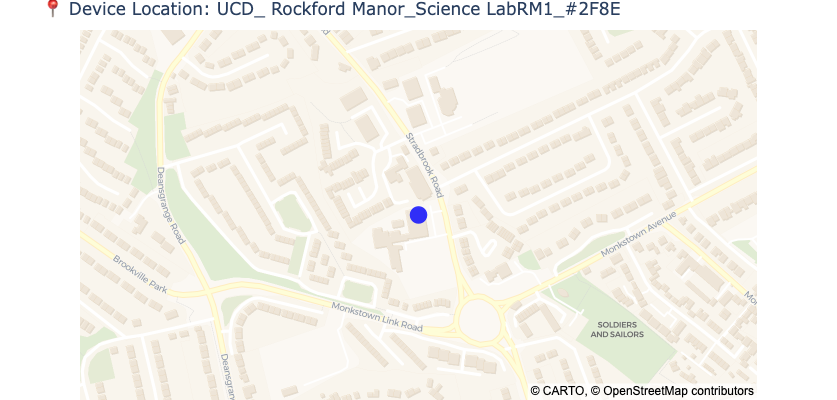

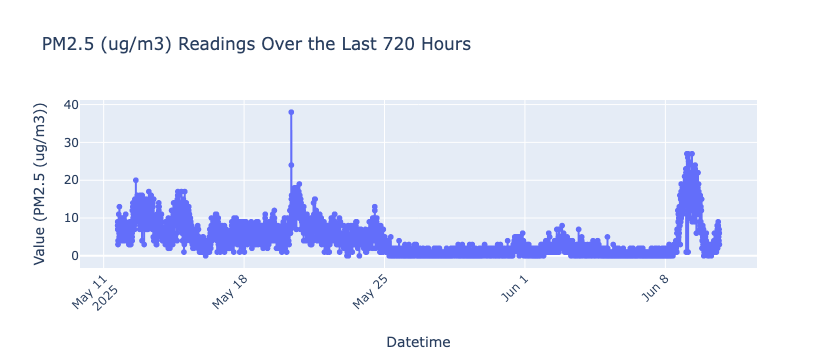

In [3]:
import io, os, requests, datetime
import pandas as pd
import plotly.express as px
from IPython.display import display, HTML

def get_sensor_data():
    try:
        # 1. User Input
        device_id = input("Enter your Smart Citizen Device ID: ").strip()
        if not device_id:
            raise ValueError("Device ID cannot be empty.")

        time_options = {
            "1": 1, "2": 8, "3": 24,
            "4": 24 * 7, "5": 24 * 15, "6": 24 * 30
        }
        print("\nTime range options:")
        [print(f"{k} - Last {v} hours") for k, v in zip(time_options, [1, 8, 24, "7 days", "15 days", "30 days"])]
        hours_back = time_options.get(input("Enter 1 to 6: ").strip())
        if not hours_back:
            raise ValueError("Invalid time range selection.")

        sensor_mapping = {
            "1": (55, "Temperature (ºC)"),
            "2": (56, "Humidity (%)"),
            "3": (58, "Pressure (kPa)"),
            "4": (89, "PM1 (ug/m3)"),
            "5": (87, "PM2.5 (ug/m3)"),
            "6": (88, "PM10 (ug/m3)"),
            "7": (112, "eCO2 (ppm)"),
            "8": (112, "TVOC (ppb)"),
            "9": (113, "Noise Level (dBA)"),
            "10": (14, "Ambient Light Sensor (lux)")
        }
        print("\nObserved properties:")
        [print(f"{k} - {v[1]}") for k, v in sensor_mapping.items()]
        sensor_choice = input("Enter the type of data number (1 to 10): ").strip()

        sensor_info = sensor_mapping.get(sensor_choice)
        if not sensor_info:
            raise ValueError("Invalid property selection.")
        sensor_id, observed_property_name = sensor_info

        # 2. API Request
        now = datetime.datetime.utcnow()
        from_time = now - datetime.timedelta(hours=hours_back)
        url = (
            f"https://api.smartcitizen.me/v0/devices/{device_id}/readings?"
            f"sensor_id={sensor_id}&rollup=5m&from={from_time:%Y-%m-%dT%H:%M:%S}&to={now:%Y-%m-%dT%H:%M:%S}"
        )
        print(f"\nFetching data from: {url}")
        data = requests.get(url).json()
        readings = data.get("readings", [])
        if not readings:
            raise ValueError("No observations found.")

        df = pd.DataFrame(readings, columns=["datetime", "value"])
        df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)
        observations_avg = df["value"].mean()

        # 3. Device metadata and map
        meta = requests.get(f"https://api.smartcitizen.me/v0/devices/{device_id}").json()
        lat, lon = meta.get("location", {}).get("latitude"), meta.get("location", {}).get("longitude")
        name = meta.get("name", f"Device {device_id}")

        if lat and lon:
            map_df = pd.DataFrame({
                "Latitude": [lat], "Longitude": [lon],
                "Device": [name], "Observed Property": [observed_property_name],
                "Avg Value": [f"{observations_avg:.2f}"]
            })
            fig_map = px.scatter_map(
                map_df, lat="Latitude", lon="Longitude",
                hover_name="Device", hover_data={"Observed Property": True, "Avg Value": True},
                zoom=15, height=400
            )
            fig_map.update_traces(marker=dict(size=18, color="blue", opacity=0.8))
            fig_map.update_layout(mapbox_style="open-street-map", title=f"📍 Device Location: {name}", margin={"t": 30, "b": 0})
            fig_map.show()
        else:
            print("No location data available.")

        # 4. Export
        os.makedirs("exports", exist_ok=True)
        safe_name = observed_property_name.replace(" ", "_").replace("º", "deg").replace("/", "-").replace(".", "")
        base = f"exports/{safe_name}_{device_id}_{from_time:%Y-%m-%d}_to_{now:%Y-%m-%d}"
        df.to_csv(f"{base}.csv", index=False)
        df.to_excel(f"{base}.xlsx", index=False)

        display(HTML(f"""
        <p><br>📥 <strong>Download your data:</strong></p>
        <ul>
            <li><a href="{base}.csv" download>CSV file</a></li>
            <li><a href="{base}.xlsx" download>Excel file</a></li>
        </ul>
        <p>Total observations retrieved: <strong>{len(df)}</strong></p>
        """))

        # 5. Plot and average
        fig = px.line(df, x='datetime', y='value',
                      title=f"{observed_property_name} Readings Over the Last {hours_back} Hours",
                      markers=True)
        fig.update_xaxes(title_text='Datetime', tickangle=-45)
        fig.update_yaxes(title_text=f"Value ({observed_property_name})")
        fig.show()

        display(HTML(
            f"<h3>Average {observed_property_name} value over the last {hours_back}h: "
            f"<strong>{observations_avg:.2f}</strong></h3><hr>"
        ))

        return df, observed_property_name, observations_avg, f"{hours_back}h", f"{from_time:%Y-%m-%dT%H:%M:%S}", f"{now:%Y-%m-%dT%H:%M:%S}"

    except requests.exceptions.RequestException as e:
        print(f"\nNetwork error: {e}")
    except ValueError as e:
        print(f"\nInput error: {e}")
    except Exception as e:
        print(f"\nUnexpected error: {e}")

    return None, None, None, None, None, None

# Run the function
readings_df, observed_property_name, observations_avg, time_interval_str, from_time_str, to_time_str = get_sensor_data()

### 🔍 Step 2: Explore the Sensor Data with Visualizations

This step provides multiple plots to help you better understand the trends, patterns, and outliers in your selected sensor data.

Depending on the selected time range, the outputs may include:

- 📊 **Histogram**: Distribution of all measurement values.
- 📈 **Rolling Average Plot**: Smoothed time series to highlight trends.
- ⏰ **Hourly Average Plot**: Average value by hour of the day (if enough hourly diversity).
- 📦 **Box Plot**: Summary of value distribution with quartiles and outliers.
- 📅 **Daily Average Time Series**: For time ranges of 7 days or more.
- 🗓️ **Calendar Heatmap**: Visualizes daily average values like a GitHub contributions chart.
- 📉 **Weekday vs Weekend Comparison**: Box plots showing differences between weekdays and weekends.
- 🚨 **Anomaly Detection**:
  - If the data is normally distributed: uses **z-score**.
  - Otherwise: uses the **IQR method** and shows a **Q-Q plot** for visual inspection.

These visual tools are meant to support data interpretation, helping users spot unusual values or daily/weekly patterns.

▶️ Run the next cell.

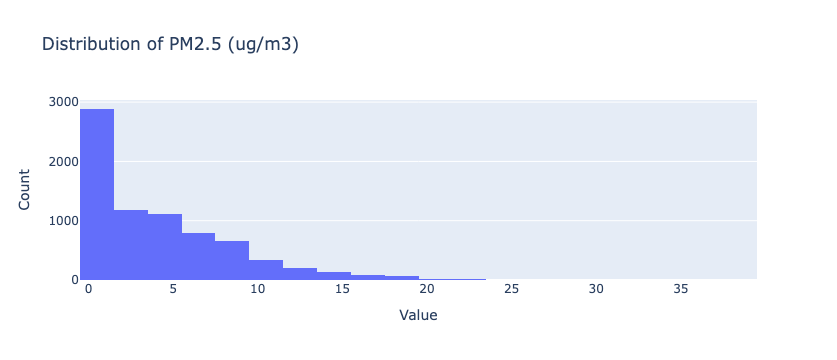

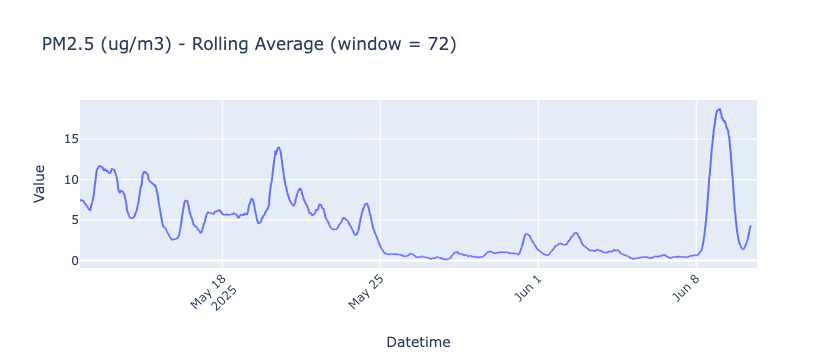

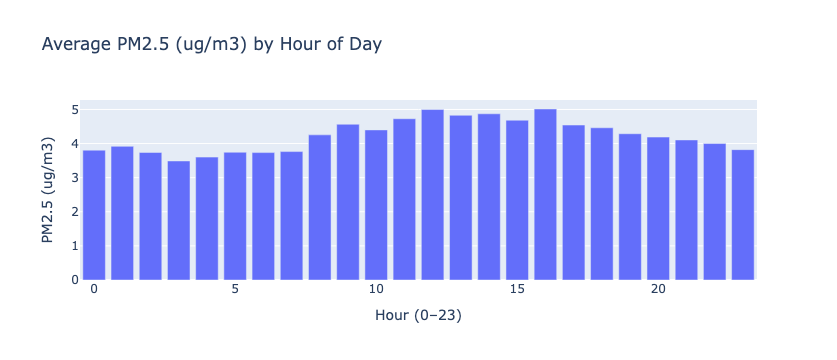

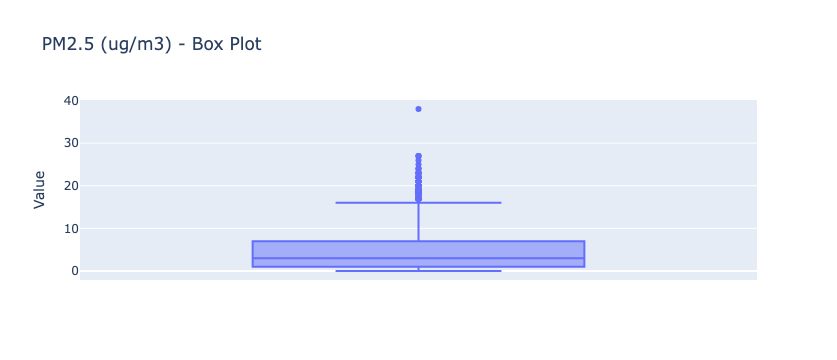

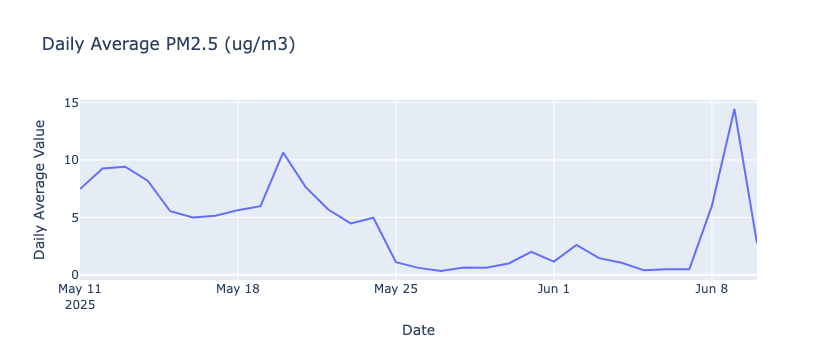

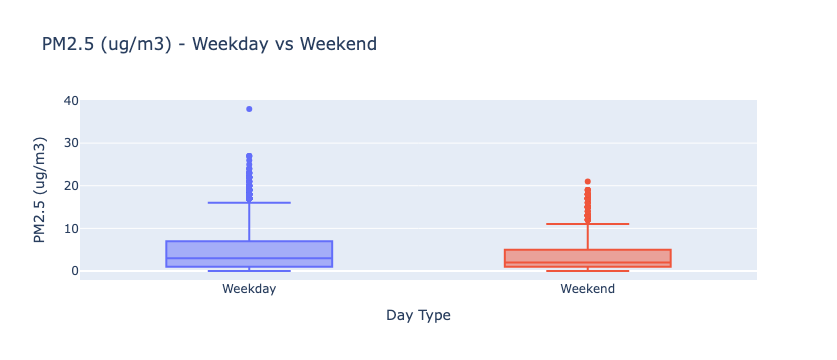

Normality test used: Normaltest | p-value = 0.0000


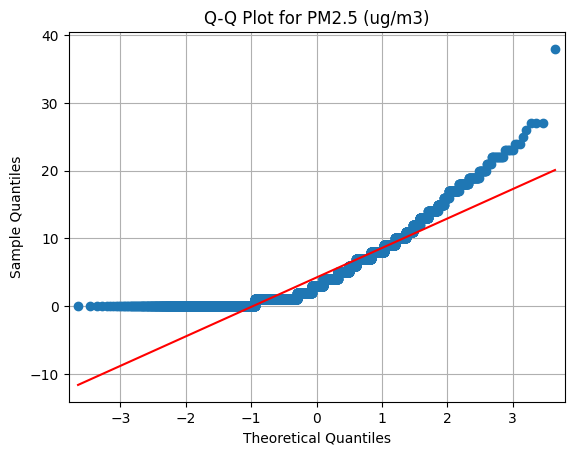

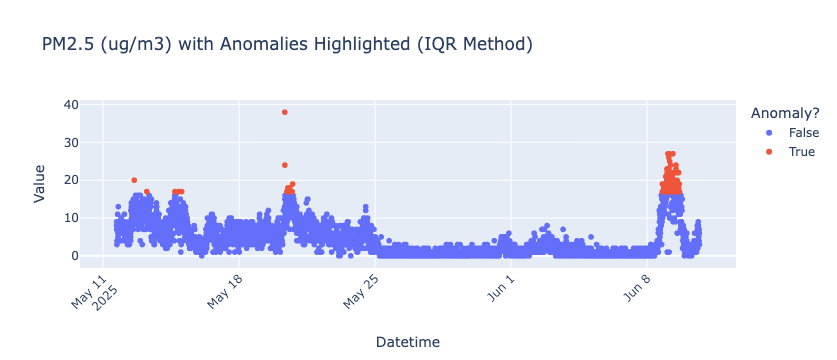

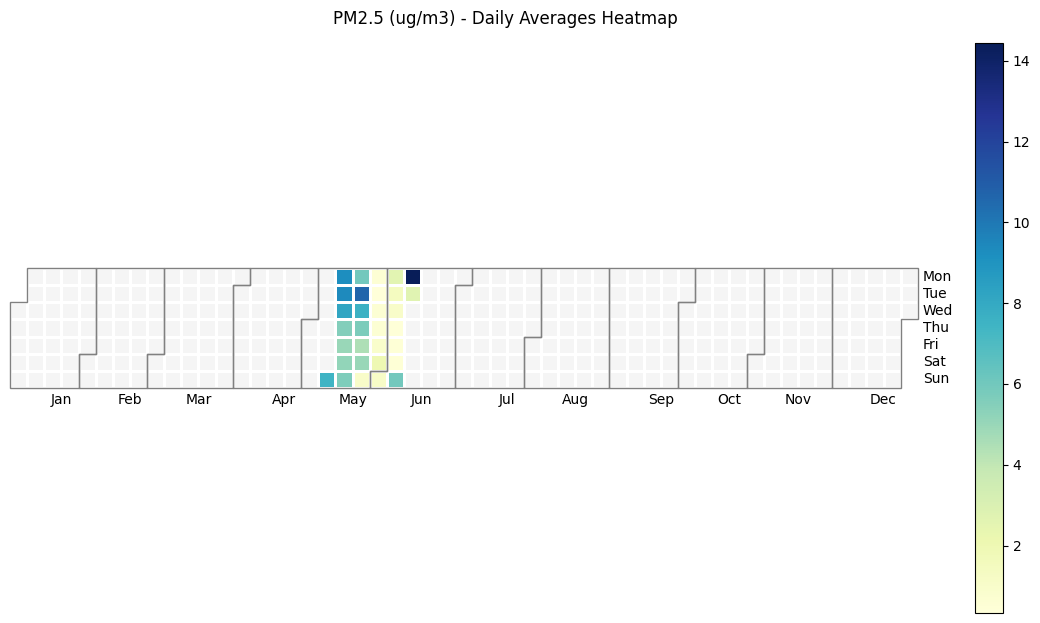

In [4]:
import numpy as np
from scipy.stats import shapiro, normaltest
import statsmodels.api as sm
import matplotlib.pyplot as plt
import calplot

if readings_df is not None:
    time_range_hours = int(time_interval_str.replace("h", ""))
    
    # 1. Histogram
    px.histogram(
        readings_df, x="value", nbins=30,
        title=f"Distribution of {observed_property_name}",
        labels={"value": f"{observed_property_name}"}
    ).update_xaxes(title_text='Value').update_yaxes(title_text='Count').show()

    # 2. Rolling average
    rolling_window = (
        3 if time_range_hours <= 1 else
        5 if time_range_hours <= 8 else
        10 if time_range_hours <= 24 else
        24 if time_range_hours <= 24 * 7 else
        48 if time_range_hours <= 24 * 15 else
        72
    )
    readings_df["rolling_avg"] = readings_df["value"].rolling(window=rolling_window).mean()

    px.line(
        readings_df, x="datetime", y="rolling_avg",
        title=f"{observed_property_name} - Rolling Average (window = {rolling_window})",
        labels={"rolling_avg": f"Smoothed {observed_property_name}"}
    ).update_xaxes(title_text='Datetime', tickangle=-45).update_yaxes(title_text='Value').show()

    # 3. Hourly pattern
    if readings_df["datetime"].dt.hour.nunique() > 2:
        hourly_avg = readings_df.assign(hour=readings_df["datetime"].dt.hour) \
            .groupby("hour")["value"].mean().reset_index()
        px.bar(
            hourly_avg, x="hour", y="value",
            title=f"Average {observed_property_name} by Hour of Day",
            labels={"value": f"{observed_property_name}", "hour": "Hour (0–23)"}
        ).show()

    # 4. Box plot
    px.box(
        readings_df, y="value",
        title=f"{observed_property_name} - Box Plot",
        labels={"value": f"{observed_property_name}"}
    ).update_yaxes(title_text='Value').show()

    # --------- Additional (7+ days) ----------
    if time_range_hours >= 24 * 7:
        # 5. Daily averages
        daily_avg = readings_df.assign(date=readings_df["datetime"].dt.date) \
            .groupby("date")["value"].mean().reset_index()

        px.line(
            daily_avg, x="date", y="value",
            title=f"Daily Average {observed_property_name}",
            labels={"value": f"{observed_property_name}", "date": "Date"}
        ).update_xaxes(title_text="Date").update_yaxes(title_text="Daily Average Value").show()

        # 6. Weekday vs Weekend
        readings_df["day_type"] = readings_df["datetime"].dt.dayofweek.apply(lambda x: "Weekend" if x >= 5 else "Weekday")
        px.box(
            readings_df, x="day_type", y="value", color="day_type",
            title=f"{observed_property_name} - Weekday vs Weekend",
            labels={"value": f"{observed_property_name}", "day_type": "Day Type"}
        ).update_layout(showlegend=False).show()

        # 7. Anomaly detection
        sample_size = len(readings_df)
        stat, p_value = shapiro(readings_df["value"]) if sample_size < 500 else normaltest(readings_df["value"])
        is_normal = p_value > 0.05
        print(f"Normality test used: {'Shapiro-Wilk' if sample_size < 500 else 'Normaltest'} | p-value = {p_value:.4f}")

        if is_normal:
            mean_val = readings_df["value"].mean()
            std_val = readings_df["value"].std()
            readings_df["is_anomaly"] = ((readings_df["value"] - mean_val) / std_val).abs() > 3
            method = "z-score > 3"
        else:
            sm.qqplot(readings_df["value"], line='s')
            plt.title(f"Q-Q Plot for {observed_property_name}")
            plt.grid(True)
            plt.show()
            Q1, Q3 = readings_df["value"].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            readings_df["is_anomaly"] = (readings_df["value"] < lower) | (readings_df["value"] > upper)
            method = "IQR Method"

        px.scatter(
            readings_df, x="datetime", y="value", color="is_anomaly",
            title=f"{observed_property_name} with Anomalies Highlighted ({method})",
            labels={"value": f"{observed_property_name}", "is_anomaly": "Anomaly?"}
        ).update_xaxes(title_text="Datetime", tickangle=-45).update_yaxes(title_text="Value").show()

    # 8. Calendar heatmap (Daily averages)
    daily_avg_series = readings_df.set_index("datetime")["value"].resample("D").mean()
    if daily_avg_series.index.tz is not None:
        daily_avg_series.index = daily_avg_series.index.tz_convert(None)
    daily_avg_series.index = daily_avg_series.index.normalize()

    calplot.calplot(
        daily_avg_series,
        cmap="YlGnBu",
        suptitle=f"{observed_property_name} - Daily Averages Heatmap",
        colorbar=True,
        figsize=(12, 4 if time_range_hours < 24 * 30 else 6),
        yearlabels=False,
        dropzero=False
    )